In [ ]:
!pip install gurobipy pandas matplotlib openpyxl

In [15]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
aircraft = pd.DataFrame({
    "Aircraft": [
        "A320",
        "B737",
        "A220"
    ],

    "Capacity": [
        180,
        174,
        140
    ],

    "Operating_Cost": [
        8500,
        8200,
        6500
    ],

    "CO2_kg": [
        5200,
        5000,
        3900
    ],

    "Available": [
        3,
        3,
        2
    ]
})

aircraft

,Aircraft,Capacity,Operating_Cost,CO2_kg,Available
0,A320,180,8500,5200,3
1,B737,174,8200,5000,3
2,A220,140,6500,3900,2


In [18]:
flights = pd.DataFrame({
    "Flight": [
        "F1",
        "F2",
        "F3",
        "F4",
        "F5",
        "F6",
        "F7",
        "F8"
    ],

    "Origin": [
        "Rome",
        "Milan",
        "Paris",
        "Madrid",
        "Rome",
        "Frankfurt",
        "Amsterdam",
        "Milan"
    ],

    "Destination": [
        "Paris",
        "Frankfurt",
        "Madrid",
        "Rome",
        "Amsterdam",
        "Madrid",
        "Rome",
        "Paris"
    ],

    "Demand": [
        155,
        160,
        125,
        170,
        120,
        150,
        130,
        145
    ]
})

flights

,Flight,Origin,Destination,Demand
0,F1,Rome,Paris,155
1,F2,Milan,Frankfurt,160
2,F3,Paris,Madrid,125
3,F4,Madrid,Rome,170
4,F5,Rome,Amsterdam,120
5,F6,Frankfurt,Madrid,150
6,F7,Amsterdam,Rome,130
7,F8,Milan,Paris,145


In [19]:
UNSERVED_PENALTY = 200

CO2_WEIGHT = 0.5

MAX_AIRCRAFT_PER_FLIGHT = 1

In [20]:
def solve_aircraft_model(demand_multiplier=1.0):

    model = gp.Model("Aircraft_Fleet_Assignment")

    # Decision variables


    x = {}

    for f in flights.index:
        for a in aircraft.index:

            x[f, a] = model.addVar(
                vtype=GRB.BINARY,
                name=f"assign_{f}_{a}"
            )

    unserved = {}

    for f in flights.index:

        unserved[f] = model.addVar(
            vtype=GRB.CONTINUOUS,
            lb=0,
            name=f"unserved_{f}"
        )

    model.update()

    # ------------------------------------------------
    # Constraint 1:
    # Each flight receives exactly one aircraft
    # ------------------------------------------------

    for f in flights.index:

        model.addConstr(
            gp.quicksum(
                x[f, a]
                for a in aircraft.index
            ) == 1,

            name=f"aircraft_assignment_{f}"
        )

    # ------------------------------------------------
    # Constraint 2:
    # Aircraft availability
    # ------------------------------------------------

    for a in aircraft.index:

        model.addConstr(
            gp.quicksum(
                x[f, a]
                for f in flights.index
            )
            <= aircraft.loc[a, "Available"],

            name=f"availability_{a}"
        )

    # ------------------------------------------------
    # Constraint 3:
    # Passenger demand and capacity
    # ------------------------------------------------

    for f in flights.index:

        demand = (
            flights.loc[f, "Demand"]
            * demand_multiplier
        )

        capacity = gp.quicksum(
            aircraft.loc[a, "Capacity"] * x[f, a]
            for a in aircraft.index
        )

        model.addConstr(
            unserved[f]
            >= demand - capacity,

            name=f"passenger_capacity_{f}"
        )

    # ------------------------------------------------
    # Objective components
    # ------------------------------------------------

    operating_cost = gp.quicksum(
        aircraft.loc[a, "Operating_Cost"] * x[f, a]
        for f in flights.index
        for a in aircraft.index
    )

    passenger_penalty = gp.quicksum(
        UNSERVED_PENALTY * unserved[f]
        for f in flights.index
    )

    emissions = gp.quicksum(
        aircraft.loc[a, "CO2_kg"] * x[f, a]
        for f in flights.index
        for a in aircraft.index
    )

    carbon_cost = CO2_WEIGHT * emissions

    # ------------------------------------------------
    # Objective
    # ------------------------------------------------

    model.setObjective(
        operating_cost
        + passenger_penalty
        + carbon_cost,

        GRB.MINIMIZE
    )

    # ------------------------------------------------
    # Solve
    # ------------------------------------------------

    model.optimize()

    # ------------------------------------------------
    # Extract results
    # ------------------------------------------------

    if model.status == GRB.OPTIMAL:

        results = []

        for f in flights.index:

            selected_aircraft = None

            for a in aircraft.index:

                if x[f, a].X > 0.5:
                    selected_aircraft = aircraft.loc[a, "Aircraft"]

            demand = (
                flights.loc[f, "Demand"]
                * demand_multiplier
            )

            capacity = aircraft[
                aircraft["Aircraft"] == selected_aircraft
            ]["Capacity"].iloc[0]

            served = min(demand, capacity)

            results.append({
                "Flight": flights.loc[f, "Flight"],
                "Origin": flights.loc[f, "Origin"],
                "Destination": flights.loc[f, "Destination"],
                "Demand": demand,
                "Aircraft": selected_aircraft,
                "Capacity": capacity,
                "Served": served,
                "Unserved": max(0, demand - capacity)
            })

        results_df = pd.DataFrame(results)

        total_demand = results_df["Demand"].sum()

        total_served = results_df["Served"].sum()

        coverage = (
            total_served /
            total_demand *
            100
        )

        return results_df, model.ObjVal, coverage

    else:

        return None, None, None

In [21]:
results, objective, coverage = solve_aircraft_model()

print("Optimal objective:", round(objective, 2))
print("Passenger coverage:", round(coverage, 2), "%")

results

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 19 rows, 32 columns and 80 nonzeros (Min)
Model fingerprint: 0xc7ad04d0
Model has 32 linear objective coefficients
Variable types: 8 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [2e+02, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+02]

Found heuristic solution: objective 85300.000000
Presolve removed 8 rows and 8 columns
Presolve time: 0.00s
Presolved: 11 rows, 24 columns, 48 nonzeros
Variable types: 0 continuous, 24 integer (24 binary)

Root relaxation: objective 8.230000e+04, 12 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | 

,Flight,Origin,Destination,Demand,Aircraft,Capacity,Served,Unserved
0,F1,Rome,Paris,155.0,A320,180,155.0,0
1,F2,Milan,Frankfurt,160.0,A320,180,160.0,0
2,F3,Paris,Madrid,125.0,A320,180,125.0,0
3,F4,Madrid,Rome,170.0,B737,174,170.0,0
4,F5,Rome,Amsterdam,120.0,A220,140,120.0,0
5,F6,Frankfurt,Madrid,150.0,B737,174,150.0,0
6,F7,Amsterdam,Rome,130.0,A220,140,130.0,0
7,F8,Milan,Paris,145.0,B737,174,145.0,0


In [22]:
def calculate_emissions(results_df):

    emissions = 0

    for _, row in results_df.iterrows():

        aircraft_name = row["Aircraft"]

        co2 = aircraft[
            aircraft["Aircraft"] == aircraft_name
        ]["CO2_kg"].iloc[0]

        emissions += co2

    return emissions


total_emissions = calculate_emissions(results)

print(
    "Total CO2 emissions:",
    total_emissions,
    "kg"
)

Total CO2 emissions: 38400 kg


In [23]:
def calculate_operating_cost(results_df):

    total_cost = 0

    for _, row in results_df.iterrows():

        aircraft_name = row["Aircraft"]

        cost = aircraft[
            aircraft["Aircraft"] == aircraft_name
        ]["Operating_Cost"].iloc[0]

        total_cost += cost

    return total_cost


total_cost = calculate_operating_cost(results)

print(
    "Total operating cost: €",
    total_cost
)

Total operating cost: € 63100


In [24]:
aircraft_usage = (
    results["Aircraft"]
    .value_counts()
    .reset_index()
)

aircraft_usage.columns = [
    "Aircraft",
    "Flights_Assigned"
]

aircraft_usage

,Aircraft,Flights_Assigned
0,A320,3
1,B737,3
2,A220,2


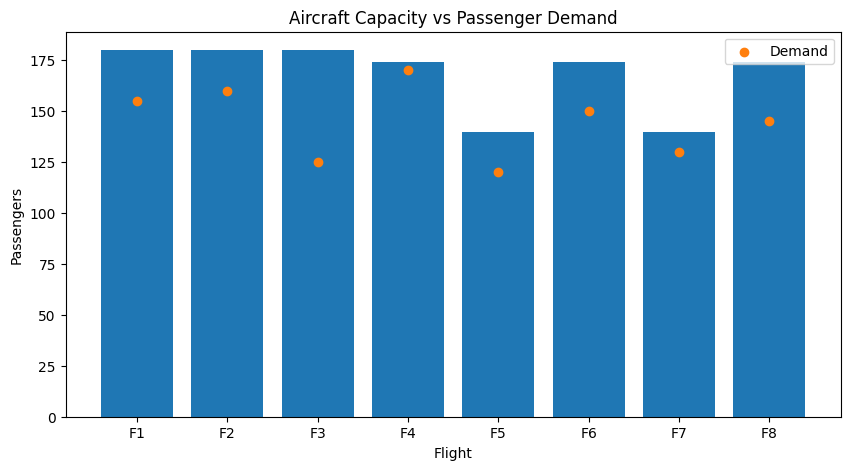

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Flight"],
    results["Capacity"]
)

plt.scatter(
    results["Flight"],
    results["Demand"],
    marker="o",
    label="Demand"
)

plt.xlabel("Flight")
plt.ylabel("Passengers")
plt.title("Aircraft Capacity vs Passenger Demand")

plt.legend()

plt.show()

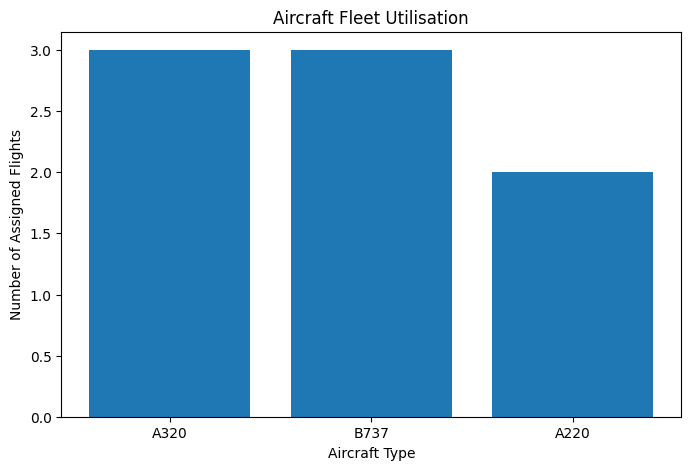

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    aircraft_usage["Aircraft"],
    aircraft_usage["Flights_Assigned"]
)

plt.xlabel("Aircraft Type")
plt.ylabel("Number of Assigned Flights")
plt.title("Aircraft Fleet Utilisation")

plt.show()

In [27]:
scenarios = {
    "Normal": 1.00,
    "High Demand": 1.15,
    "Very High Demand": 1.30
}

scenario_results = []

for scenario, multiplier in scenarios.items():

    results_s, objective_s, coverage_s = (
        solve_aircraft_model(multiplier)
    )

    total_emissions_s = calculate_emissions(results_s)

    total_cost_s = calculate_operating_cost(results_s)

    total_unserved_s = results_s["Unserved"].sum()

    scenario_results.append({
        "Scenario": scenario,
        "Demand_Multiplier": multiplier,
        "Objective": objective_s,
        "Coverage_%": coverage_s,
        "Unserved_Passengers": total_unserved_s,
        "Operating_Cost": total_cost_s,
        "CO2_kg": total_emissions_s
    })

scenario_df = pd.DataFrame(scenario_results)

scenario_df

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 19 rows, 32 columns and 80 nonzeros (Min)
Model fingerprint: 0xc7ad04d0
Model has 32 linear objective coefficients
Variable types: 8 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [2e+02, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+02]

Found heuristic solution: objective 85300.000000
Presolve removed 8 rows and 8 columns
Presolve time: 0.00s
Presolved: 11 rows, 24 columns, 48 nonzeros
Variable types: 0 continuous, 24 integer (24 binary)

Root relaxation: objective 8.230000e+04, 12 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | 

,Scenario,Demand_Multiplier,Objective,Coverage_%,Unserved_Passengers,Operating_Cost,CO2_kg
0,Normal,1.00,82300.0,100.000000,0.00,63100,38400
1,High Demand,1.15,86950.0,98.249577,23.25,63100,38400
2,Very High Demand,1.30,115200.0,89.044289,164.50,63100,38400


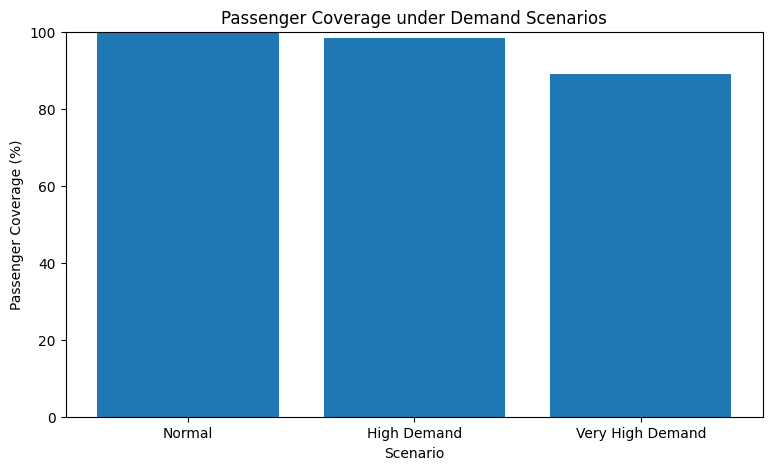

In [28]:
plt.figure(figsize=(9, 5))

plt.bar(
    scenario_df["Scenario"],
    scenario_df["Coverage_%"]
)

plt.ylabel("Passenger Coverage (%)")
plt.xlabel("Scenario")

plt.title(
    "Passenger Coverage under Demand Scenarios"
)

plt.ylim(0, 100)

plt.show()

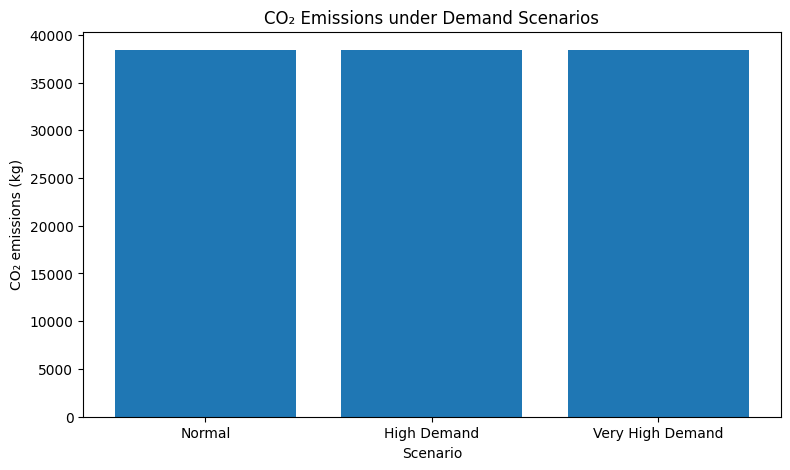

In [29]:
plt.figure(figsize=(9, 5))

plt.bar(
    scenario_df["Scenario"],
    scenario_df["CO2_kg"]
)

plt.ylabel("CO₂ emissions (kg)")
plt.xlabel("Scenario")

plt.title(
    "CO₂ Emissions under Demand Scenarios"
)

plt.show()